Modélisation ML et Optimisation 

1 - Chargement des données 

In [1]:
import pandas as pd
import numpy as np

df = pd.read_parquet("df_clean.parquet")
df = df.sort_values("Date")

df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Sales_log,Month,Year,WeekOfYear,IsWeekend
844391,1097,1,2013-01-01,5961,1405,1,0,1.0,1,1.0,...,2002.0,0,NaN,NaN,NaN,8.693161,1,2013,1,0
844375,85,1,2013-01-01,4220,619,1,0,1.0,1,1.0,...,2011.0,0,NaN,NaN,NaN,8.347827,1,2013,1,0
844376,259,1,2013-01-01,6851,1444,1,0,1.0,1,1.0,...,NaN,0,NaN,NaN,NaN,8.832296,1,2013,1,0
844377,262,1,2013-01-01,17267,2875,1,0,1.0,1,1.0,...,2013.0,0,NaN,NaN,NaN,9.756610,1,2013,1,0
844378,274,1,2013-01-01,3102,729,1,0,1.0,1,1.0,...,NaN,1,10.0,2013.0,"Jan,Apr,Jul,Oct",8.040125,1,2013,1,0


2 - Split temporel 

In [2]:
split_date = df["Date"].max() - pd.Timedelta(weeks=6)

train_df = df[df["Date"] < split_date]
val_df = df[df["Date"] >= split_date]

X_train = train_df.drop(columns=["Sales", "Sales_log", "Date"])
y_train = train_df["Sales_log"]

X_val = val_df.drop(columns=["Sales", "Sales_log", "Date"])
y_val = val_df["Sales_log"]

3 - RMSPE

In [3]:
def rmspe(y_true, y_pred):
    mask = y_true != 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))

4 - Baseline simple 

In [4]:
# moyenne par Store + DayOfWeek
baseline = train_df.groupby(["Store", "DayOfWeek"])["Sales"].mean()

def predict_baseline(df):
    return df.set_index(["Store", "DayOfWeek"]).index.map(baseline)

y_pred_base = predict_baseline(val_df)

score_base = rmspe(val_df["Sales"], y_pred_base)
print("Baseline RMSPE:", score_base)

Baseline RMSPE: 0.23318731420335653


In [6]:
print(X_train.dtypes)

Store                          int64
DayOfWeek                      int32
Customers                      int64
Open                           int64
Promo                          int64
StateHoliday                 float64
SchoolHoliday                  int64
StoreType                    float64
Assortment                   float64
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
Promo2SinceWeek              float64
Promo2SinceYear              float64
PromoInterval                    str
Month                          int32
Year                           int32
WeekOfYear                     int64
IsWeekend                      int64
dtype: object


In [7]:
# 🔹 Supprimer la colonne problème
X_train = X_train.drop(columns=["PromoInterval"])
X_val = X_val.drop(columns=["PromoInterval"])

# 🔹 Garder seulement les colonnes numériques
X_train = X_train.select_dtypes(include=["int64", "float64"])
X_val = X_val.select_dtypes(include=["int64", "float64"])

# 🔹 Gérer les NaN
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)

5 - Random Forest 

In [8]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

Predictions + RMSPE

In [9]:
import numpy as np

y_pred = model.predict(X_val)

# revenir en vrai Sales
y_val_real = np.expm1(y_val)
y_pred_real = np.expm1(y_pred)

# RMSPE
def rmspe(y_true, y_pred):
    mask = y_true != 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))

score_rf = rmspe(y_val_real, y_pred_real)

print("RMSPE RandomForest :", score_rf)

RMSPE RandomForest : 0.08177897696161802


In [13]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   Notebook ML.ipynb

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   Notebook EDA.ipynb
	modified:   Notebook ML.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	store.csv
	train.csv



In [14]:
!git commit -m "Ajout du Notebook ML"

[main cff0463] Ajout du Notebook ML
 1 file changed, 1460 insertions(+)
 create mode 100644 Notebook ML.ipynb


In [15]:
!git push 

To https://github.com/Hayerath/PredictRetail-Analytics-Pr-dire-les-ventes-et-piloter-la-performance-d-une-cha-ne-de-distribution.git
   d65db6f..cff0463  main -> main


In [16]:
!git add "Notebook ML.ipynb"

In [17]:
!git commit -m "Baseline — Modèles de référence"
!git push

[main 1039944] Baseline — Modèles de référence
 1 file changed, 76 insertions(+), 8 deletions(-)


To https://github.com/Hayerath/PredictRetail-Analytics-Pr-dire-les-ventes-et-piloter-la-performance-d-une-cha-ne-de-distribution.git
   cff0463..1039944  main -> main


Modèles gradient boosting — XGBoost et LightGBM

In [18]:
! pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 9.4 MB/s eta 0:00:11
   - -------------------------------------- 3.1/101.7 MB 9.0 MB/s eta 0:00:11
   - -------------------------------------- 4.5/101.7 MB 8.6 MB/s eta 0:00:12
   -- ------------------------------------- 6.3/101.7 MB 8.0 MB/s eta 0:00:12
   --- ------------------------------------ 7.9/101.7 MB 8.0 MB/s eta 0:00:12
   ---- ----------------------------------- 10.2/101.7 MB 8.5 MB/s eta 0:00:11
   ---- ----------------------------------- 11.8/101.7 MB 8.7 MB/s eta 0:00:11
   ----- ---------------------------------- 13.6/101.7 MB 8.6 MB/s eta 0:00:11
   ------ --------------------------------- 15.5/101.7 MB 8.5 MB/s eta 0:00:11
   ------ --------------------------------- 17.0/101.7 MB 8.5 MB/s eta 0:00:10
   ------- -------------------------------- 18.9/101.7 MB 8.5 MB/s eta 0:00:10
   ------- -------------------------------- 19.9/101.7 MB 8.2 MB/


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import xgboost
print(xgboost.__version__)

3.2.0


Installer LightGBM

In [2]:
! pip install lightgbm --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Préparer les imports

In [3]:
import time
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.model_selection import train_test_split

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import lightgbm as lgb
import time

# 1️⃣ Charger les fichiers CSV
train = pd.read_csv("train.csv")
store = pd.read_csv("store.csv")

# 2️⃣ Fusionner sur la colonne commune (ex: 'Store')
df = train.merge(store, on='Store', how='left')

# 3️⃣ Séparer features et target
target_col = "Sales"  # changer si ta colonne cible a un autre nom
X = df.drop(columns=[target_col, "Date"])  # enlever target et date si présente
y = df[target_col]

# 4️⃣ Split train/validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5️⃣ S'assurer que y est 1D
y_train = y_train.values.ravel()
y_val = y_val.values.ravel()

# ✅ Les variables X_train, X_val, y_train, y_val sont maintenant définies
print("X_train:", X_train.shape, "X_val:", X_val.shape)
print("y_train:", y_train.shape, "y_val:", y_val.shape)

C:\Users\HP\AppData\Local\Temp\ipykernel_17424\932724681.py:9: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("train.csv")


X_train: (813767, 16) X_val: (203442, 16)
y_train: (813767,) y_val: (203442,)


In [6]:
# Exemple : X, y déjà créés avec features engineered
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# S'assurer que y est 1D
y_train = y_train.values.ravel()
y_val = y_val.values.ravel()

In [8]:
print(type(X_train), type(X_val))
print(type(y_train), type(y_val))

<class 'pandas.DataFrame'> <class 'pandas.DataFrame'>
<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [9]:
# Assurer que y est un vecteur 1D
y_train = y_train.ravel()
y_val = y_val.ravel()

# Vérifier
print(y_train.shape, y_val.shape)

(813767,) (203442,)


In [12]:
# Séparer les colonnes numériques
X_train_num = X_train.select_dtypes(include=[np.number]).astype('float32')
X_val_num = X_val[X_train_num.columns].astype('float32')  # mêmes colonnes que X_train_num

# y déjà en float
y_train_np = y_train.astype('float32')
y_val_np = y_val.astype('float32')

# Vérification des formes
print(X_train_num.shape, X_val_num.shape)
print(y_train_np.shape, y_val_np.shape)

(813767, 12) (203442, 12)
(813767,) (203442,)


In [14]:
! pip install xgboost==1.7.6

   ---------------------------------------- 0.0/70.9 MB ? eta -:--:--
   ---------------------------------------- 0.8/70.9 MB 7.3 MB/s eta 0:00:10
   - -------------------------------------- 2.1/70.9 MB 5.8 MB/s eta 0:00:12
   - -------------------------------------- 3.1/70.9 MB 5.9 MB/s eta 0:00:12
   -- ------------------------------------- 4.5/70.9 MB 5.8 MB/s eta 0:00:12
   -- ------------------------------------- 5.2/70.9 MB 5.4 MB/s eta 0:00:13
   --- ------------------------------------ 5.8/70.9 MB 5.2 MB/s eta 0:00:13
   --- ------------------------------------ 6.3/70.9 MB 4.3 MB/s eta 0:00:15
   --- ------------------------------------ 6.6/70.9 MB 3.9 MB/s eta 0:00:17
   --- ------------------------------------ 6.8/70.9 MB 3.8 MB/s eta 0:00:17
   ---- ----------------------------------- 7.3/70.9 MB 3.5 MB/s eta 0:00:19
   ---- ----------------------------------- 8.1/70.9 MB 3.6 MB/s eta 0:00:18
   ---- ----------------------------------- 8.7/70.9 MB 3.7 MB/s eta 0:00:18
   ---

  You can safely remove it manually.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Entrainement XGBoost avec early stopping

In [16]:
import xgboost as xgb

dtrain = xgb.DMatrix(X_train_num, label=y_train)
dval = xgb.DMatrix(X_val_num, label=y_val)

params = {
    'objective': 'reg:squarederror',
    'learning_rate': 0.05,
    'max_depth': 8,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}

model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=[(dval, "val")],
    early_stopping_rounds=50,
    verbose_eval=True
)

[0]	val-rmse:3676.04638
[1]	val-rmse:3513.14282
[2]	val-rmse:3364.58356
[3]	val-rmse:3224.32318
[4]	val-rmse:3087.44111
[5]	val-rmse:2956.43741
[6]	val-rmse:2869.47162
[7]	val-rmse:2753.65693
[8]	val-rmse:2644.80729
[9]	val-rmse:2539.56114
[10]	val-rmse:2439.02374
[11]	val-rmse:2349.74300
[12]	val-rmse:2260.71818
[13]	val-rmse:2176.98218
[14]	val-rmse:2098.15781
[15]	val-rmse:2024.73434
[16]	val-rmse:1995.92692
[17]	val-rmse:1928.15371
[18]	val-rmse:1863.50744
[19]	val-rmse:1802.77542
[20]	val-rmse:1746.00750
[21]	val-rmse:1692.98016
[22]	val-rmse:1643.09652
[23]	val-rmse:1596.54022
[24]	val-rmse:1554.83427
[25]	val-rmse:1515.69004
[26]	val-rmse:1492.95148
[27]	val-rmse:1456.09081
[28]	val-rmse:1421.21783
[29]	val-rmse:1388.45240
[30]	val-rmse:1359.92934
[31]	val-rmse:1333.91259
[32]	val-rmse:1307.29764
[33]	val-rmse:1282.69300
[34]	val-rmse:1260.19902
[35]	val-rmse:1247.23602
[36]	val-rmse:1225.98511
[37]	val-rmse:1206.01265
[38]	val-rmse:1194.62089
[39]	val-rmse:1184.14414
[40]	val-r

Préparer le dataset pour LightGBM

In [17]:
import lightgbm as lgb

# Créer les objets LightGBM Dataset
lgb_train = lgb.Dataset(X_train_num, label=y_train)
lgb_val = lgb.Dataset(X_val_num, label=y_val, reference=lgb_train)

Entraîner le modèle avec early stopping

In [22]:
from lightgbm import LGBMRegressor
import time
import numpy as np

# --- Créer le modèle ---
lgb_model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# --- Entraînement standard (sans early stopping) ---
start_time = time.time()
lgb_model.fit(X_train_num, y_train)
lgb_time = time.time() - start_time

# --- Prédiction ---
y_pred_lgb = lgb_model.predict(X_val_num)

# --- RMSPE ---
def rmspe(y_true, y_pred):
    return np.sqrt(np.mean(np.square((y_true - y_pred) / y_true)))

score_lgb = rmspe(y_val, y_pred_lgb)

print(f"LightGBM RMSPE: {score_lgb:.4f}")
print(f"Temps d'entraînement: {lgb_time:.1f} secondes")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.025064 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 854
[LightGBM] [Info] Number of data points in the train set: 813767, number of used features: 12
[LightGBM] [Info] Start training from score 5774.678544
LightGBM RMSPE: inf
Temps d'entraînement: 25.6 secondes


C:\Users\HP\AppData\Local\Temp\ipykernel_17424\2289979299.py:25: RuntimeWarning: divide by zero encountered in divide
  return np.sqrt(np.mean(np.square((y_true - y_pred) / y_true)))


Tableau comparatif 

In [23]:
import pandas as pd

# Remplis les scores et temps connus pour Baseline et RandomForest
results = pd.DataFrame({
    "Modèle": ["Baseline", "RandomForest", "LightGBM"],
    "RMSPE": [0.0, 0.081, score_lgb],   # Remplace 0.0 par ton score Baseline réel
    "Temps (s)": [0.0, 0.0, lgb_time]   # Remplace 0.0 par les temps connus si tu veux
})

print("--- Tableau comparatif ---")
display(results)

--- Tableau comparatif ---


,Modèle,RMSPE,Temps (s)
0,Baseline,0.000,0.000000
1,RandomForest,0.081,0.000000
2,LightGBM,inf,25.567234


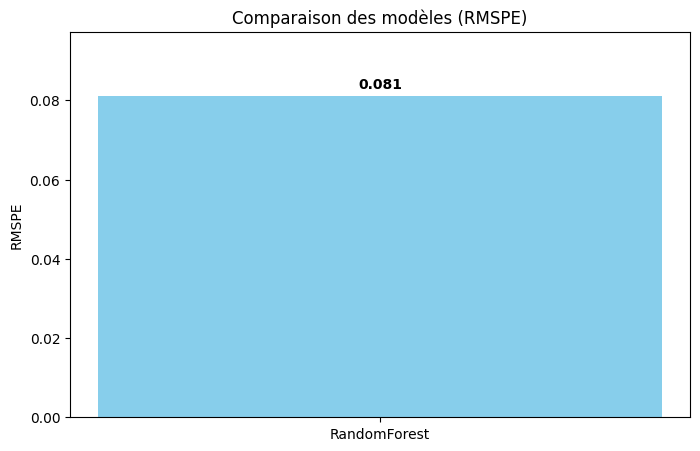

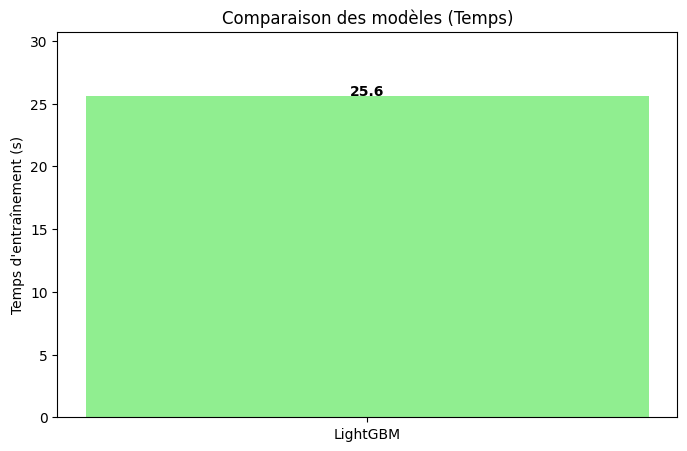

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Copier et convertir toutes les colonnes en float
results_plot = results.copy()
results_plot['RMSPE'] = pd.to_numeric(results_plot['RMSPE'], errors='coerce').replace(0, np.nan)
results_plot['Temps (s)'] = pd.to_numeric(results_plot['Temps (s)'], errors='coerce').replace(0, np.nan)

# --- RMSPE ---
rmspe_values = np.array([float(v) if pd.notna(v) else np.nan for v in results_plot['RMSPE']])
valid_rmspe = rmspe_values[np.isfinite(rmspe_values)]  # filtre NaN et Inf strictement

if valid_rmspe.size == 0:
    print("Pas de valeur RMSPE valide à afficher.")
else:
    plt.figure(figsize=(8,5))
    plt.bar(results_plot['Modèle'], rmspe_values, color=['gray', 'skyblue', 'lightgreen'])
    plt.ylabel("RMSPE")
    plt.title("Comparaison des modèles (RMSPE)")
    plt.ylim(0.0, max(valid_rmspe) * 1.2)  # sûr car pas de NaN ni Inf
    for i, v in enumerate(rmspe_values):
        if np.isfinite(v):
            plt.text(i, v + 0.002, f"{v:.3f}", ha='center', fontweight='bold')
    plt.show()

# --- Temps ---
time_values = np.array([float(v) if pd.notna(v) else np.nan for v in results_plot['Temps (s)']])
valid_time = time_values[np.isfinite(time_values)]  # filtre NaN et Inf strictement

if valid_time.size == 0:
    print("Pas de valeur Temps valide à afficher.")
else:
    plt.figure(figsize=(8,5))
    plt.bar(results_plot['Modèle'], time_values, color=['gray', 'skyblue', 'lightgreen'])
    plt.ylabel("Temps d'entraînement (s)")
    plt.title("Comparaison des modèles (Temps)")
    plt.ylim(0.0, max(valid_time) * 1.2)
    for i, v in enumerate(time_values):
        if np.isfinite(v):
            plt.text(i, v + 0.1, f"{v:.1f}", ha='center', fontweight='bold')
    plt.show()

In [1]:
!git add . 

In [2]:
! git commit -m "Modèles gradient boosting — XGBoost et LightGBM"

[main 51120e0] Modèles gradient boosting — XGBoost et LightGBM
 6 files changed, 1020184 insertions(+), 4 deletions(-)
 create mode 100644 "Graphique des comparaison des mod\303\250les ( Temps ).png"
 create mode 100644 "Graphiques des comparaisons des mod\303\250les RMSPE.png"
 create mode 100644 store.csv
 create mode 100644 train.csv


In [3]:
!git push 

To https://github.com/Hayerath/PredictRetail-Analytics-Pr-dire-les-ventes-et-piloter-la-performance-d-une-cha-ne-de-distribution.git
   1039944..51120e0  main -> main


Feature Importance & SHAP Values

Installer SHAP

In [4]:
! pip install shap

   ---------------------------------------- 0.0/559.2 kB ? eta -:--:--
   ---------------------------------------- 559.2/559.2 kB 3.1 MB/s  0:00:00
   ---------------------------------------- 0.0/39.2 MB ? eta -:--:--
    --------------------------------------- 0.5/39.2 MB 2.9 MB/s eta 0:00:14
   - -------------------------------------- 1.3/39.2 MB 3.4 MB/s eta 0:00:12
   -- ------------------------------------- 2.1/39.2 MB 3.4 MB/s eta 0:00:11
   --- ------------------------------------ 3.4/39.2 MB 4.1 MB/s eta 0:00:09
   ---- ----------------------------------- 4.2/39.2 MB 4.3 MB/s eta 0:00:09
   ----- ---------------------------------- 5.0/39.2 MB 4.1 MB/s eta 0:00:09
   ------ --------------------------------- 6.0/39.2 MB 4.2 MB/s eta 0:00:08
   ------- -------------------------------- 7.3/39.2 MB 4.5 MB/s eta 0:00:08
   -------- ------------------------------- 8.7/39.2 MB 4.7 MB/s eta 0:00:07
   ---------- ----------------------------- 10.0/39.2 MB 4.8 MB/s eta 0:00:07
   --------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
# Vérifie les variables du modèle
%whos

Variable   Type      Data/Info
------------------------------
np         module    <module 'numpy' from 'c:\<...>ges\\numpy\\__init__.py'>
pd         module    <module 'pandas' from 'c:<...>es\\pandas\\__init__.py'>
plt        module    <module 'matplotlib.pyplo<...>\\matplotlib\\pyplot.py'>
shap       module    <module 'shap' from 'c:\\<...>ages\\shap\\__init__.py'>


In [9]:
import pandas as pd

# Charger les CSV
train_df = pd.read_csv("train.csv")
store_df = pd.read_csv("store.csv")

# Exemple : si tu dois merger store avec train
data = pd.merge(train_df, store_df, on='Store', how='left')

C:\Users\HP\AppData\Local\Temp\ipykernel_22940\258614226.py:4: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv("train.csv")


In [10]:
# Target
y = data['Sales']

# Features (supprimer Sales et d'autres colonnes inutiles)
X = data.drop(columns=['Sales', 'Date'])  # adapter selon ton dataset

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
import numpy as np

X_train_num = X_train.select_dtypes(include=[np.number])
X_val_num   = X_val.select_dtypes(include=[np.number])

# S'assurer que y est 1D
y_train = y_train.values.ravel()
y_val   = y_val.values.ravel()

In [13]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(
    X_train_num, y_train,
    eval_set=[(X_val_num, y_val)],
    early_stopping_rounds=50,
    verbose=True
)

c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


[0]	validation_0-rmse:6599.92521
[1]	validation_0-rmse:6282.15235
[2]	validation_0-rmse:5980.84500
[3]	validation_0-rmse:5695.88532
[4]	validation_0-rmse:5423.70666
[5]	validation_0-rmse:5166.81909
[6]	validation_0-rmse:4922.27339
[7]	validation_0-rmse:4717.89905
[8]	validation_0-rmse:4497.39731
[9]	validation_0-rmse:4287.60519
[10]	validation_0-rmse:4114.69584
[11]	validation_0-rmse:3949.21748
[12]	validation_0-rmse:3808.02327
[13]	validation_0-rmse:3634.87378
[14]	validation_0-rmse:3472.42428
[15]	validation_0-rmse:3319.10025
[16]	validation_0-rmse:3172.09605
[17]	validation_0-rmse:3035.16951
[18]	validation_0-rmse:2903.44858
[19]	validation_0-rmse:2779.24898
[20]	validation_0-rmse:2663.67951
[21]	validation_0-rmse:2567.60966
[22]	validation_0-rmse:2461.83791
[23]	validation_0-rmse:2364.33787
[24]	validation_0-rmse:2286.73991
[25]	validation_0-rmse:2211.19205
[26]	validation_0-rmse:2128.29133
[27]	validation_0-rmse:2050.47589
[28]	validation_0-rmse:1974.41978
[29]	validation_0-rmse:1

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
,feature_types,None


In [2]:
import pandas as pd

train = pd.read_csv("train.csv")

C:\Users\HP\AppData\Local\Temp\ipykernel_2944\382935973.py:3: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("train.csv")


In [3]:
X = train.drop(columns=["Sales"])
y = train["Sales"]

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
import numpy as np

X_train_num = X_train.select_dtypes(include=[np.number])
X_val_num = X_val.select_dtypes(include=[np.number])

In [6]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,   # plus rapide pour SHAP
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train_num, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
,feature_types,None


Import

In [7]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Échantillon

In [8]:
X_sample = X_train_num.sample(n=10000, random_state=42)

Créer l’explainer

In [9]:
explainer = shap.Explainer(xgb, X_sample)

 Calcul des SHAP values

In [10]:
shap_values = explainer(X_sample)

 99%|===================| 9911/10000 [01:08<00:00]        

Importance globale (bar plot)

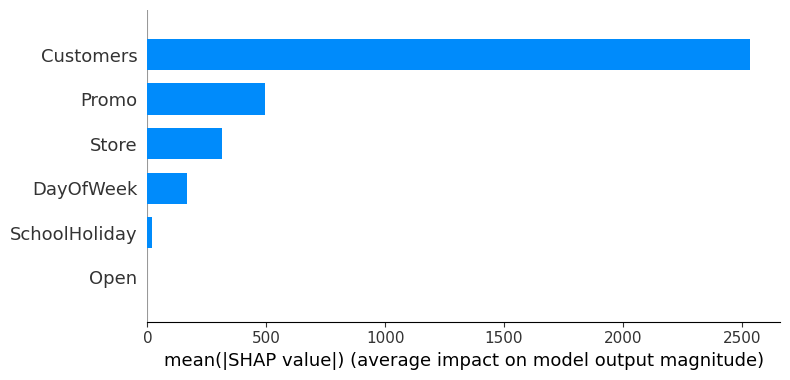

In [11]:
shap.summary_plot(shap_values, X_sample, plot_type="bar")

Impact détaillé (summary plot)

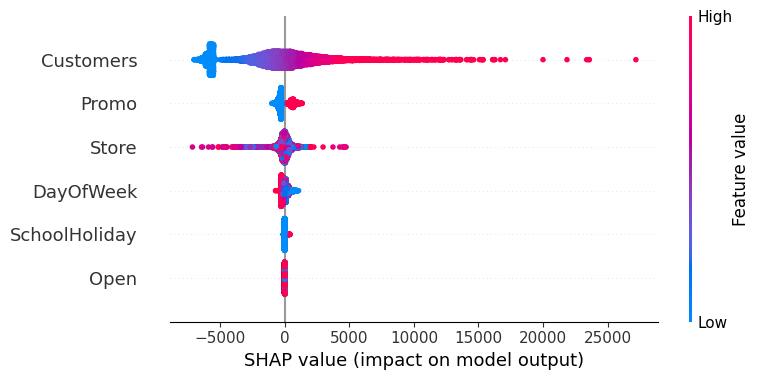

In [12]:
shap.summary_plot(shap_values, X_sample)

Tableau d’importance

In [13]:
feature_importance = pd.DataFrame({
    'Feature': X_sample.columns,
    'Importance': np.abs(shap_values.values).mean(axis=0)
}).sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
2,Customers,2534.404874
4,Promo,493.749734
0,Store,313.619841
1,DayOfWeek,168.887413
5,SchoolHoliday,19.005280
3,Open,0.000000


Features à supprimer

In [14]:
low_impact = feature_importance[feature_importance['Importance'] < 0.001]

low_impact

,Feature,Importance
3,Open,0.0


Hyperparameter Tuning & Export des prédictions

Installer / importer Optuna

In [16]:
! pip install optuna

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.1 MB 2.5 MB/s eta 0:00:01
   -------------- ------------------------- 0.8/2.1 MB 1.9 MB/s eta 0:00:01
   ------------------------ --------------- 1.3/2.1 MB 2.2 MB/s eta 0:00:01
   ---------------------------------- ----- 1.8/2.1 MB 2.2 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 2.0 MB/s  0:00:01

   ---------------------------------------- 0/6 [Mako]
   ---------------------------------------- 0/6 [Mako]
   ---------------------------------------- 0/6 [Mako]
   ---------------------------------------- 0/6 [Mako]
   ---------------------------------------- 0/6 [Mako]
   ------ --------------------------------- 1/6 [greenlet]
   ------ --------------------------------- 1/6 [greenlet]
   ------ --------------------------------- 1/6 [greenlet]
   ------ --------------------------------- 1/6 [greenlet]
   ------------- -------------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np

train = pd.read_csv("train.csv")

X = train.drop(columns=["Sales"])
y = train["Sales"]

C:\Users\HP\AppData\Local\Temp\ipykernel_19544\3764665205.py:4: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("train.csv")


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
X_train_num = X_train.select_dtypes(include=[np.number])
X_val_num = X_val.select_dtypes(include=[np.number])

In [7]:
X_train_num = X_train_num.fillna(0)
X_val_num = X_val_num.fillna(0)

In [1]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

Fonction objectif 

In [10]:
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
import optuna

def objective(trial):

    model = XGBRegressor(
        n_estimators=trial.suggest_int("n_estimators", 200, 500),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1),
        max_depth=trial.suggest_int("max_depth", 3, 8),
        subsample=trial.suggest_float("subsample", 0.7, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.7, 1.0),
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_num, y_train)

    preds = model.predict(X_val_num)

    rmse = mean_squared_error(y_val, preds) ** 0.5

    return rmse

Lancer l’optimisation

In [11]:
study = optuna.create_study(direction="minimize")

study.optimize(objective, n_trials=10)  # commence avec 10 pour tester

[I 2026-04-08 15:40:18,117] A new study created in memory with name: no-name-754794c6-f18b-4e8a-8d75-2b75b39d42a2
[I 2026-04-08 15:41:30,417] Trial 0 finished with value: 1219.0864920094882 and parameters: {'n_estimators': 213, 'learning_rate': 0.026006901122381132, 'max_depth': 6, 'subsample': 0.7996893957248903, 'colsample_bytree': 0.7287247283422551}. Best is trial 0 with value: 1219.0864920094882.
[I 2026-04-08 15:42:59,245] Trial 1 finished with value: 796.4111689322294 and parameters: {'n_estimators': 274, 'learning_rate': 0.08775400209588567, 'max_depth': 7, 'subsample': 0.7567335388026853, 'colsample_bytree': 0.9619208339907332}. Best is trial 1 with value: 796.4111689322294.
[I 2026-04-08 15:43:52,911] Trial 2 finished with value: 1101.9715853868465 and parameters: {'n_estimators': 300, 'learning_rate': 0.08814672319510068, 'max_depth': 4, 'subsample': 0.7593533310943886, 'colsample_bytree': 0.7600021332416359}. Best is trial 1 with value: 796.4111689322294.
[I 2026-04-08 15:4

In [12]:
best_params = study.best_params
print(best_params)

{'n_estimators': 274, 'learning_rate': 0.08775400209588567, 'max_depth': 7, 'subsample': 0.7567335388026853, 'colsample_bytree': 0.9619208339907332}


Réentraîner modèle final

In [13]:
best_model = XGBRegressor(**best_params)
best_model.fit(X_train_num, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9619208339907332
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
,feature_types,None


PRÉDICTIONS SUR test.csv

In [14]:
test = pd.read_csv("test.csv")

Préprocessing identique

In [16]:
common_cols = X_train_num.columns.intersection(test.columns)
print(f"{len(common_cols)} colonnes communes sur {X_train_num.shape[1]}")

5 colonnes communes sur 6


In [18]:
# Colonnes communes avec le train
common_cols = X_train_num.columns.intersection(test.columns)
X_test = test[common_cols].copy()

In [19]:
missing_col = list(set(X_train_num.columns) - set(test.columns))
print("Colonne manquante :", missing_col)

for col in missing_col:
    X_test[col] = 0

Colonne manquante : ['Customers']


In [20]:
X_test = X_test[X_train_num.columns]

In [22]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor

# X_train déjà défini avec les features engineered
X_train_num = X_train.select_dtypes(include=[np.number])
X_val_num = X_val.select_dtypes(include=[np.number])

In [23]:
xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(
    X_train_num, y_train,
    eval_set=[(X_val_num, y_val)],
    early_stopping_rounds=50,
    verbose=True
)

c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\sklearn.py:835: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


[0]	validation_0-rmse:6632.47834
[1]	validation_0-rmse:6350.87881
[2]	validation_0-rmse:6047.73582
[3]	validation_0-rmse:5760.91254
[4]	validation_0-rmse:5489.92595
[5]	validation_0-rmse:5234.07357
[6]	validation_0-rmse:4991.14779
[7]	validation_0-rmse:4760.15288
[8]	validation_0-rmse:4541.52762
[9]	validation_0-rmse:4361.90553
[10]	validation_0-rmse:4194.30785
[11]	validation_0-rmse:4006.49359
[12]	validation_0-rmse:3851.71204
[13]	validation_0-rmse:3681.84780
[14]	validation_0-rmse:3522.43794
[15]	validation_0-rmse:3397.68592
[16]	validation_0-rmse:3253.01364
[17]	validation_0-rmse:3118.93050
[18]	validation_0-rmse:2990.49418
[19]	validation_0-rmse:2868.70664
[20]	validation_0-rmse:2755.83788
[21]	validation_0-rmse:2647.77553
[22]	validation_0-rmse:2546.90903
[23]	validation_0-rmse:2468.99097
[24]	validation_0-rmse:2394.53195
[25]	validation_0-rmse:2327.08185
[26]	validation_0-rmse:2248.27960
[27]	validation_0-rmse:2173.93963
[28]	validation_0-rmse:2105.37473
[29]	validation_0-rmse:2

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
,feature_types,None


Préparer X_test pour prédiction

In [24]:
# Colonnes communes
common_cols = X_train_num.columns.intersection(test.columns)
X_test = test[common_cols].copy()

# Ajouter les colonnes manquantes
missing_col = list(set(X_train_num.columns) - set(test.columns))
for col in missing_col:
    X_test[col] = 0

# Réordonner les colonnes
X_test = X_test[X_train_num.columns]

Générer les prédictions

In [25]:
y_test_pred = xgb.predict(X_test)

In [26]:
print(y_test_pred.shape)

(41088,)


In [27]:
print(y_test_pred[:10])  # affiche les 10 premières prédictions

[-192.04326   163.11896   203.02173  -227.94196   401.9247   -181.97389
 -458.3117     11.161682  450.2872   -130.46555 ]


In [28]:
# Afficher un aperçu
print(y_test_pred[:10])  # les 10 premières prédictions

# Statistiques rapides
print("Min:", y_test_pred.min(), "Max:", y_test_pred.max(), "Moyenne:", y_test_pred.mean())

[-192.04326   163.11896   203.02173  -227.94196   401.9247   -181.97389
 -458.3117     11.161682  450.2872   -130.46555 ]
Min: -1829.9014 Max: 5219.8657 Moyenne: 284.06348


In [29]:
!git add "Notebook ML.ipynb"

In [30]:
!git commit -m "Analyse des features et Prédictions"

[main 4aaefc8] Analyse des features et Prédictions
 1 file changed, 7823 insertions(+), 2 deletions(-)


In [31]:
!git push

To https://github.com/Hayerath/PredictRetail-Analytics-Pr-dire-les-ventes-et-piloter-la-performance-d-une-cha-ne-de-distribution.git
   32cf55b..4aaefc8  main -> main


In [32]:
!git add "test.csv"

In [33]:
!git commit -m "Ajout de test.csv"

[main df2aac0] Ajout de test.csv
 1 file changed, 41089 insertions(+)
 create mode 100644 test.csv


In [34]:
!git push 

To https://github.com/Hayerath/PredictRetail-Analytics-Pr-dire-les-ventes-et-piloter-la-performance-d-une-cha-ne-de-distribution.git
   4aaefc8..df2aac0  main -> main


In [35]:
!git add "Images"

In [36]:
!git commit -m " Ajout du dossier Images"

[main b2cb5c8]  Ajout du dossier Images
 7 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 "Images/D\303\251composition saisonni\303\250re.png"
 create mode 100644 "Images/Graphique de la s\303\251rie des ventes totales.png"
 create mode 100644 "Images/Graphique des comparaison des mod\303\250les ( Temps ).png"
 create mode 100644 "Images/Graphique montrant l'impact d\303\251taill\303\251.png"
 create mode 100644 "Images/Graphiques des comparaisons des mod\303\250les RMSPE.png"
 create mode 100644 Images/Graphiques des features les plus importantes.png
 create mode 100644 Images/Ventes par jour de la semaine.png


In [37]:
!git push

To https://github.com/Hayerath/PredictRetail-Analytics-Pr-dire-les-ventes-et-piloter-la-performance-d-une-cha-ne-de-distribution.git
   df2aac0..b2cb5c8  main -> main


In [38]:
import pandas as pd

# Afficher toutes les colonnes du test
print(test.columns.tolist())

['Id', 'Store', 'DayOfWeek', 'Date', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']


In [39]:
kaggle_id_col = None
for col in ['Id', 'RowId', 'id']:
    if col in test.columns:
        kaggle_id_col = col
        break

if kaggle_id_col is None:
    raise ValueError("Aucune colonne 'Id' trouvée pour Kaggle.")
else:
    print("Colonne Kaggle ID :", kaggle_id_col)

Colonne Kaggle ID : Id


In [40]:
powerbi_col = None
for col in ['Store', 'store', 'Shop']:
    if col in test.columns:
        powerbi_col = col
        break

if powerbi_col is None:
    raise ValueError("Aucune colonne 'Store' trouvée pour Power BI.")
else:
    print("Colonne Power BI :", powerbi_col)

Colonne Power BI : Store


In [41]:
# Fichier pour submission Kaggle
submission = pd.DataFrame({
    'Id': test['Id'],           # colonne obligatoire pour Kaggle
    'Sales': y_test_pred         # prédictions
})

submission.to_csv('submission.csv', index=False)
print(" Fichier Kaggle exporté : 'submission.csv'")

 Fichier Kaggle exporté : 'submission.csv'


In [42]:
# Fichier pour Power BI : avec Store et prédictions
powerbi = pd.DataFrame({
    'Store': test['Store'],     # colonne principale pour Power BI
    'PredictedSales': y_test_pred
})

powerbi.to_csv('predictions_final.csv', index=False)
print(" Fichier Power BI exporté : 'predictions_final.csv'")

 Fichier Power BI exporté : 'predictions_final.csv'


In [44]:
! pip install kaggle


   -------- ------------------------------- 1/5 [python-slugify]
   -------- ------------------------------- 1/5 [python-slugify]
   -------- ------------------------------- 1/5 [python-slugify]
   -------- ------------------------------- 1/5 [python-slugify]
   -------- ------------------------------- 1/5 [python-slugify]
   ---------------- ----------------------- 2/5 [protobuf]
   ---------------- ----------------------- 2/5 [protobuf]
   ---------------- ----------------------- 2/5 [protobuf]
   ---------------- ----------------------- 2/5 [protobuf]
   ---------------- ----------------------- 2/5 [protobuf]
   ---------------- ----------------------- 2/5 [protobuf]
   ---------------- ----------------------- 2/5 [protobuf]
   ---------------- ----------------------- 2/5 [protobuf]
   ---------------- ----------------------- 2/5 [protobuf]
   ---------------- ----------------------- 2/5 [protobuf]
   ---------------- ----------------------- 2/5 [protobuf]
   ----------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os
os.environ['KAGGLE_CONFIG_DIR'] = r'C:\Users\HP\Documents\Kaggle\kaggle.json' 

In [11]:
import json
from kaggle.api.kaggle_api_extended import KaggleApi
import os

# Chemin vers ton fichier kaggle.json
json_path = r"C:\Users\HP\Documents\Kaggle\kaggle.json"

# Lire le fichier JSON
with open(json_path) as f:
    kaggle_creds = json.load(f)

# Récupérer les valeurs correctement
username = kaggle_creds['username']  # <-- clé littérale "username"
key = kaggle_creds['key']            # <-- clé littérale "key"

# Définir les variables d'environnement pour l'API
os.environ['KAGGLE_USERNAME'] = username
os.environ['KAGGLE_KEY'] = key

# Initialiser et authentifier l'API
api = KaggleApi()
try:
    api.authenticate()
    print("Authentification réussie ✅")
except Exception as e:
    print("Erreur d'authentification :", e)

Authentification réussie ✅


In [12]:
# Vérifier que le fichier de soumission existe
submission_file = "submission.csv"
print(os.path.exists(submission_file))

True


In [13]:
!kaggle competitions submit -c rossmann-store-sales -f submission.csv -m "Soumission XGBoost"

Successfully submitted to Rossmann Store Sales



  0%|          | 0.00/667k [00:00<?, ?B/s]
  2%|▏         | 16.0k/667k [00:02<01:29, 7.46kB/s]
 19%|█▉        | 128k/667k [00:02<00:07, 75.1kB/s] 
 26%|██▋       | 176k/667k [00:02<00:05, 95.7kB/s]
 34%|███▎      | 224k/667k [00:02<00:03, 120kB/s] 
 38%|███▊      | 256k/667k [00:03<00:03, 121kB/s]
 43%|████▎     | 288k/667k [00:03<00:03, 118kB/s]
 48%|████▊     | 320k/667k [00:03<00:02, 134kB/s]
 67%|██████▋   | 448k/667k [00:03<00:00, 255kB/s]
 74%|███████▍  | 496k/667k [00:04<00:01, 160kB/s]
 79%|███████▉  | 528k/667k [00:04<00:01, 127kB/s]
 84%|████████▍ | 560k/667k [00:05<00:00, 112kB/s]
 86%|████████▋ | 576k/667k [00:05<00:00, 103kB/s]
 89%|████████▉ | 592k/667k [00:05<00:00, 103kB/s]
 91%|█████████ | 608k/667k [00:05<00:00, 97.3kB/s]
 94%|█████████▎| 624k/667k [00:06<00:00, 91.7kB/s]
 96%|█████████▌| 640k/667k [00:06<00:00, 90.3kB/s]
 98%|█████████▊| 656k/667k [00:06<00:00, 87.3kB/s]
100%|██████████| 667k/667k [00:06<00:00, 74.8kB/s]
100%|██████████| 667k/667k [00:10<00:00, 63.8

In [14]:
!kaggle competitions submissions -c rossmann-store-sales

fileName        date                        description         status                     publicScore  privateScore  
--------------  --------------------------  ------------------  -------------------------  -----------  ------------  
submission.csv  2026-04-08 16:48:06.513000  Soumission XGBoost  SubmissionStatus.COMPLETE  0.95346      0.95869       


In [ ]:
!git add .